# NB1 - Data Preprocessing
## Goal of NB 1
- import libraries
- set dataset path
- Resize images
- normalize pixel values
- Create training and validation data set


# Import libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

# Create image generator

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

**ImageDataGenerator** was applied to improve model generalization and prevent overfitting. For rescaling, the range [0,1] by dividing by 255. **20%** of the dataset is for validation. For data argumentation, rotation up to 20 degree, horizontal and vertical shifting is 10 %, zoom variation up to 20 % and horizontal flipping.

## Create Training Data set

In [18]:
data_dir = "C:/Projects/06_WildLife_Image_Classification/Wildlife_images"
train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

Found 2134 images belonging to 12 classes.


The dataset was loaded using **flow_from_directory** , which automatically reads images from class-based folders, resizes them to 224x224 pixels.

# Create Validation Data set

In [20]:
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

val_data = val_datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

Found 530 images belonging to 12 classes.


For validation dataset, use **ImageDataGenerator** and **flow_from_directory** just like the previous one.

# Check Dataset

In [21]:
print(train_data.class_indices)

{'bear': 0, 'cheetah': 1, 'chimpanzee': 2, 'crocodile': 3, 'deer': 4, 'eagle': 5, 'elephant': 6, 'fox': 7, 'giraffe': 8, 'kangaroo': 9, 'snake': 10, 'wolf': 11}


The class label and their corresponding numeric encoding were printed.


# Show Sample Images

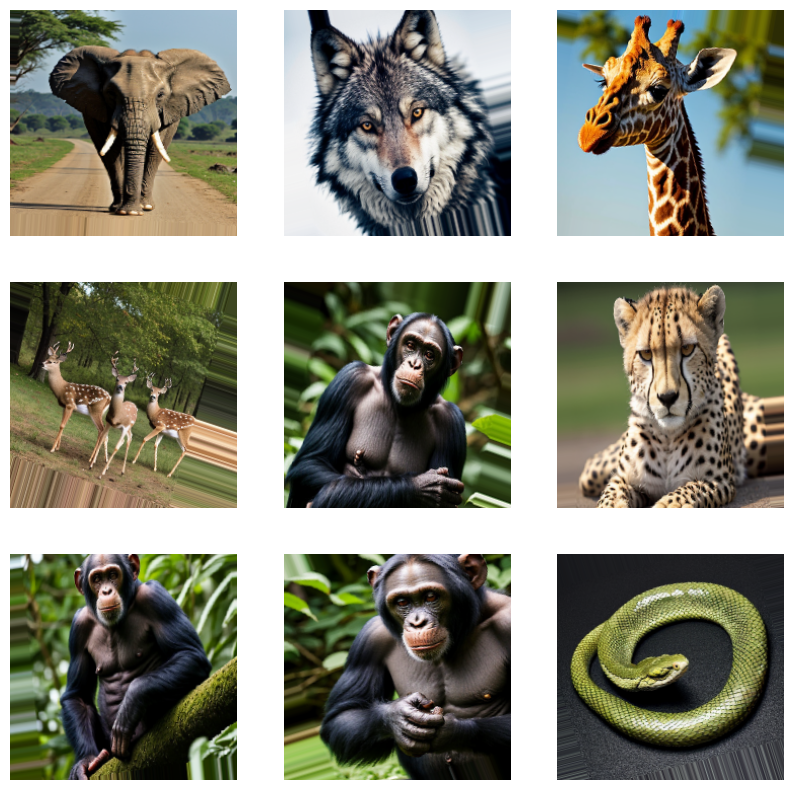

In [22]:
images, labels = next(train_data)

plt.figure(figsize=(10,10))

for i in range(9) :
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")
plt.show()

Images are loaded in 3x3 grid to check the training sample data set and verify that preprocessing step was applied correctly.